<a href="https://colab.research.google.com/github/nhartman94/scaling-laws-demo/blob/main/notebooks/01_scaling_laws.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Click the badge above to run this notebook in Google Colab. Then run the setup cell below first.*

In [ ]:
# === Colab setup — run this first. Does nothing when run locally. ===
import sys, os
if "google.colab" in sys.modules:
    REPO = "/content/scaling-laws-demo"
    if not os.path.exists(REPO):
        !git clone -q https://github.com/nhartman94/scaling-laws-demo.git {REPO}
    # Pin matplotlib to Colab's preinstalled build. Otherwise mplhep upgrades it,
    # and upgrading an already-imported library mid-session leaves stale modules
    # (e.g. 'cannot import name FontPath from matplotlib.font_manager').
    import matplotlib
    %pip install -q -e {REPO} "matplotlib=={matplotlib.__version__}"
    # add repo to sys.path so the import works in THIS kernel without a restart
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    # cd into notebooks/ so the ../results relative paths resolve
    %cd {REPO}/notebooks


# Extracting neural scaling laws three ways on a cheap toy example

A neural **scaling law** predicts how the achievable loss falls as you spend more
**compute** $C(N,D)$[FLOPs], and *how to spend it*: at each budget there is an optimal split between
**model size** $N$ (parameters) and **data** $D$ (examples seen). For the matmul-dominated
cost of training an MLP of width $w$ and input dimension $d$ we use $C = (6N - 2dw)\,D$. The object
of interest is the **compute-optimal frontier** $L^\star(C)$ and the allocation
$(N^\star(C), D^\star(C))$ that reaches it.

> **Sanity-check the FLOP formula.** A closed form like this is convenient but architecture-specific. It is good practice to first verify it against a real measurement (e.g. PyTorch's `FlopCounterMode`) — and if they differ a lot, or compute is hard to track analytically for a custom model, just **use the measured FLOPs**. We run exactly that check in the [appendix](#flop-appendix) at the end.

The Chinchilla paper extracts this **three ways**; this notebook reproduces all three on a
tiny synthetic task — training MLPs of growing size — that runs on a laptop:

1. **Training-curve envelope** — assumption-free; the lower envelope of the loss-vs-compute curves.
2. **IsoFLOP profiles** — at fixed $C$, sweep $N$; the loss-minimising $N$ is $N^\star(C)$.
3. **Parametric fit** — fit $L(N,D)=L_\infty+A/N^\alpha+B/D^\beta$ and read the frontier off in closed form.

Option (3) the parametric fit we covered in the lecture.

>
> **This notebook only visualises and explains.** Training happens in scripts:
> ```
> python scripts/run_hp_study.py     # calibrate the per-cell LR law (results/hp_study_cosine.json)
> python scripts/run_sweep.py        # train the (N,D) grid -> results/sweep_cosine.csv
> ```

We'll guide you in the notebook exercises when to refer back and to implement exercises in these scripts.

## 1. The synthetic problem: a Gaussian teacher–student

Inputs are standard Gaussian, $x\sim\mathcal N(0,I_d)$. The target comes from a **fixed,
frozen network** — the *teacher* — plus label noise:

$$y = f_\text{teacher}(x) + \sigma\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,1).$$

The teacher is never trained; it just *defines the ground-truth function* (a fixed, seeded
network whose weights are saved to `results/teacher.pt`). The
**student** is the MLP we train, of growing width $N$. The clean target is normalised to unit
variance.

This gives a clean additive law $L\approx L_\infty + A/N^\alpha + B/D^\beta$:

| term | meaning | controlled by |
|------|---------|---------------|
| $A/N^\alpha$ | a small student can't represent the teacher | student width vs teacher width |
| $B/D^\beta$  | too few examples to pin the function down | single-pass budget $D$ |
| $E$          | label noise no model can predict | noise $\sigma$ |

<font color="red"><b>Q1:</b></font> What is $\mathcal{L}_\infty$ for this problem?

<font color="blue"><b>Soln:</b> the Bayes-optimal predictor is $f_\text{teacher}$, so
$E=\sigma^2$ — which lets us grade the fitted floor (Approach 3).</font>

In [2]:
import sys
# Colab: ensure the cloned repo is importable even if the setup cell above is stale
if "google.colab" in sys.modules and "/content/scaling-laws-demo" not in sys.path:
    sys.path.insert(0, "/content/scaling-laws-demo")

import os, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

from scaling_laws.sweep import aggregate
from scaling_laws import approaches as ap, plotting as pl

pl.set_style()

# Colab uses Python 3.12, whose stdlib dropped 'imp'; older IPython autoreload
# still imports it. Alias imp -> importlib (provides reload) so %load_ext works.
import importlib
sys.modules.setdefault("imp", importlib)

# Hot-reload your edits to scaling_laws/*.py. Exclude the matplotlib stack
%load_ext autoreload
%autoreload 2
%aimport -matplotlib, -mpl_toolkits, -mplhep

In [8]:
RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"

meta = json.load(open(os.path.join(RESULTS, "sweep_meta.json"))) # setup / params we save for you

E_true = .01   # YOUR ANSWER TO Q1 HERE!
agg = aggregate(pd.read_csv(os.path.join(RESULTS, "sweep_cosine.csv")))
print(f"teacher width {meta['problem']['teacher_width']}, noise sigma={meta['problem']['noise_std']}")
print(f"KNOWN irreducible loss  E = sigma^2 = {E_true}")
print(f"grid: {agg['N'].nunique()} model sizes x {agg['D'].nunique()} data sizes, "
      f"N from {agg['N'].min()} to {agg['N'].max()} params")
agg #.head()

teacher width 256, noise sigma=0.1
KNOWN irreducible loss  E = sigma^2 = 0.01
grid: 6 model sizes x 15 data sizes, N from 345 to 280065 params


,width,n_hidden,N,D,iso_C,C,batch_size,steps,val_loss,val_loss_std,init_loss
0,8,2,345,1024,0.0,1.595392e+06,256,4,0.768011,0.050542,1.024455
1,8,2,345,2048,0.0,3.190784e+06,256,8,0.453767,0.098634,1.024455
2,8,2,345,4096,0.0,6.381568e+06,256,16,0.295766,0.056638,1.024455
3,8,2,345,8192,0.0,1.276314e+07,256,32,0.225090,0.011497,1.024455
4,8,2,345,16384,0.0,2.552627e+07,256,64,0.192331,0.002066,1.024455
...,...,...,...,...,...,...,...,...,...,...,...
85,512,2,280065,1048576,0.0,1.727657e+12,256,4096,0.014574,0.002154,0.982207
86,512,2,280065,2097152,0.0,3.455314e+12,256,8192,0.013283,0.001735,0.982207
87,512,2,280065,4194304,0.0,6.910628e+12,256,16384,0.012455,0.001335,0.982207
88,512,2,280065,8388608,0.0,1.382126e+13,256,32768,0.011809,0.000821,0.982207


## First: a fair grid needs per-cell hyperparameters

Before extracting any scaling law, every cell must be trained near *its own* optimal
hyperparameters, otherwise mis-tuning biases the fitted exponents.

The compute-optimal loss at fixed model size $N$,
$$L^\star_{\rm cell}(N,D)\;=\;\min_{b,\eta}\,L_{\rm final}(N,D,b,\eta),$$
is **not** the loss-vs-$D$ trajectory of one training run. It is the *lower envelope* of many
runs, each separately tuned $(b,\eta)$ for its own target $D$. A single run
with one fixed $(b,\eta)$ lies *above* that envelope everywhere except at the one $D$ it was tuned
for. So as you grow $D$ you must re-tune, there is no free "just train longer".

The figure below is this construction: each coloured curve is a run tuned for one
target $D$ (circle = its endpoint), and $L^\star_{\rm cell}$ threads the endpoints.

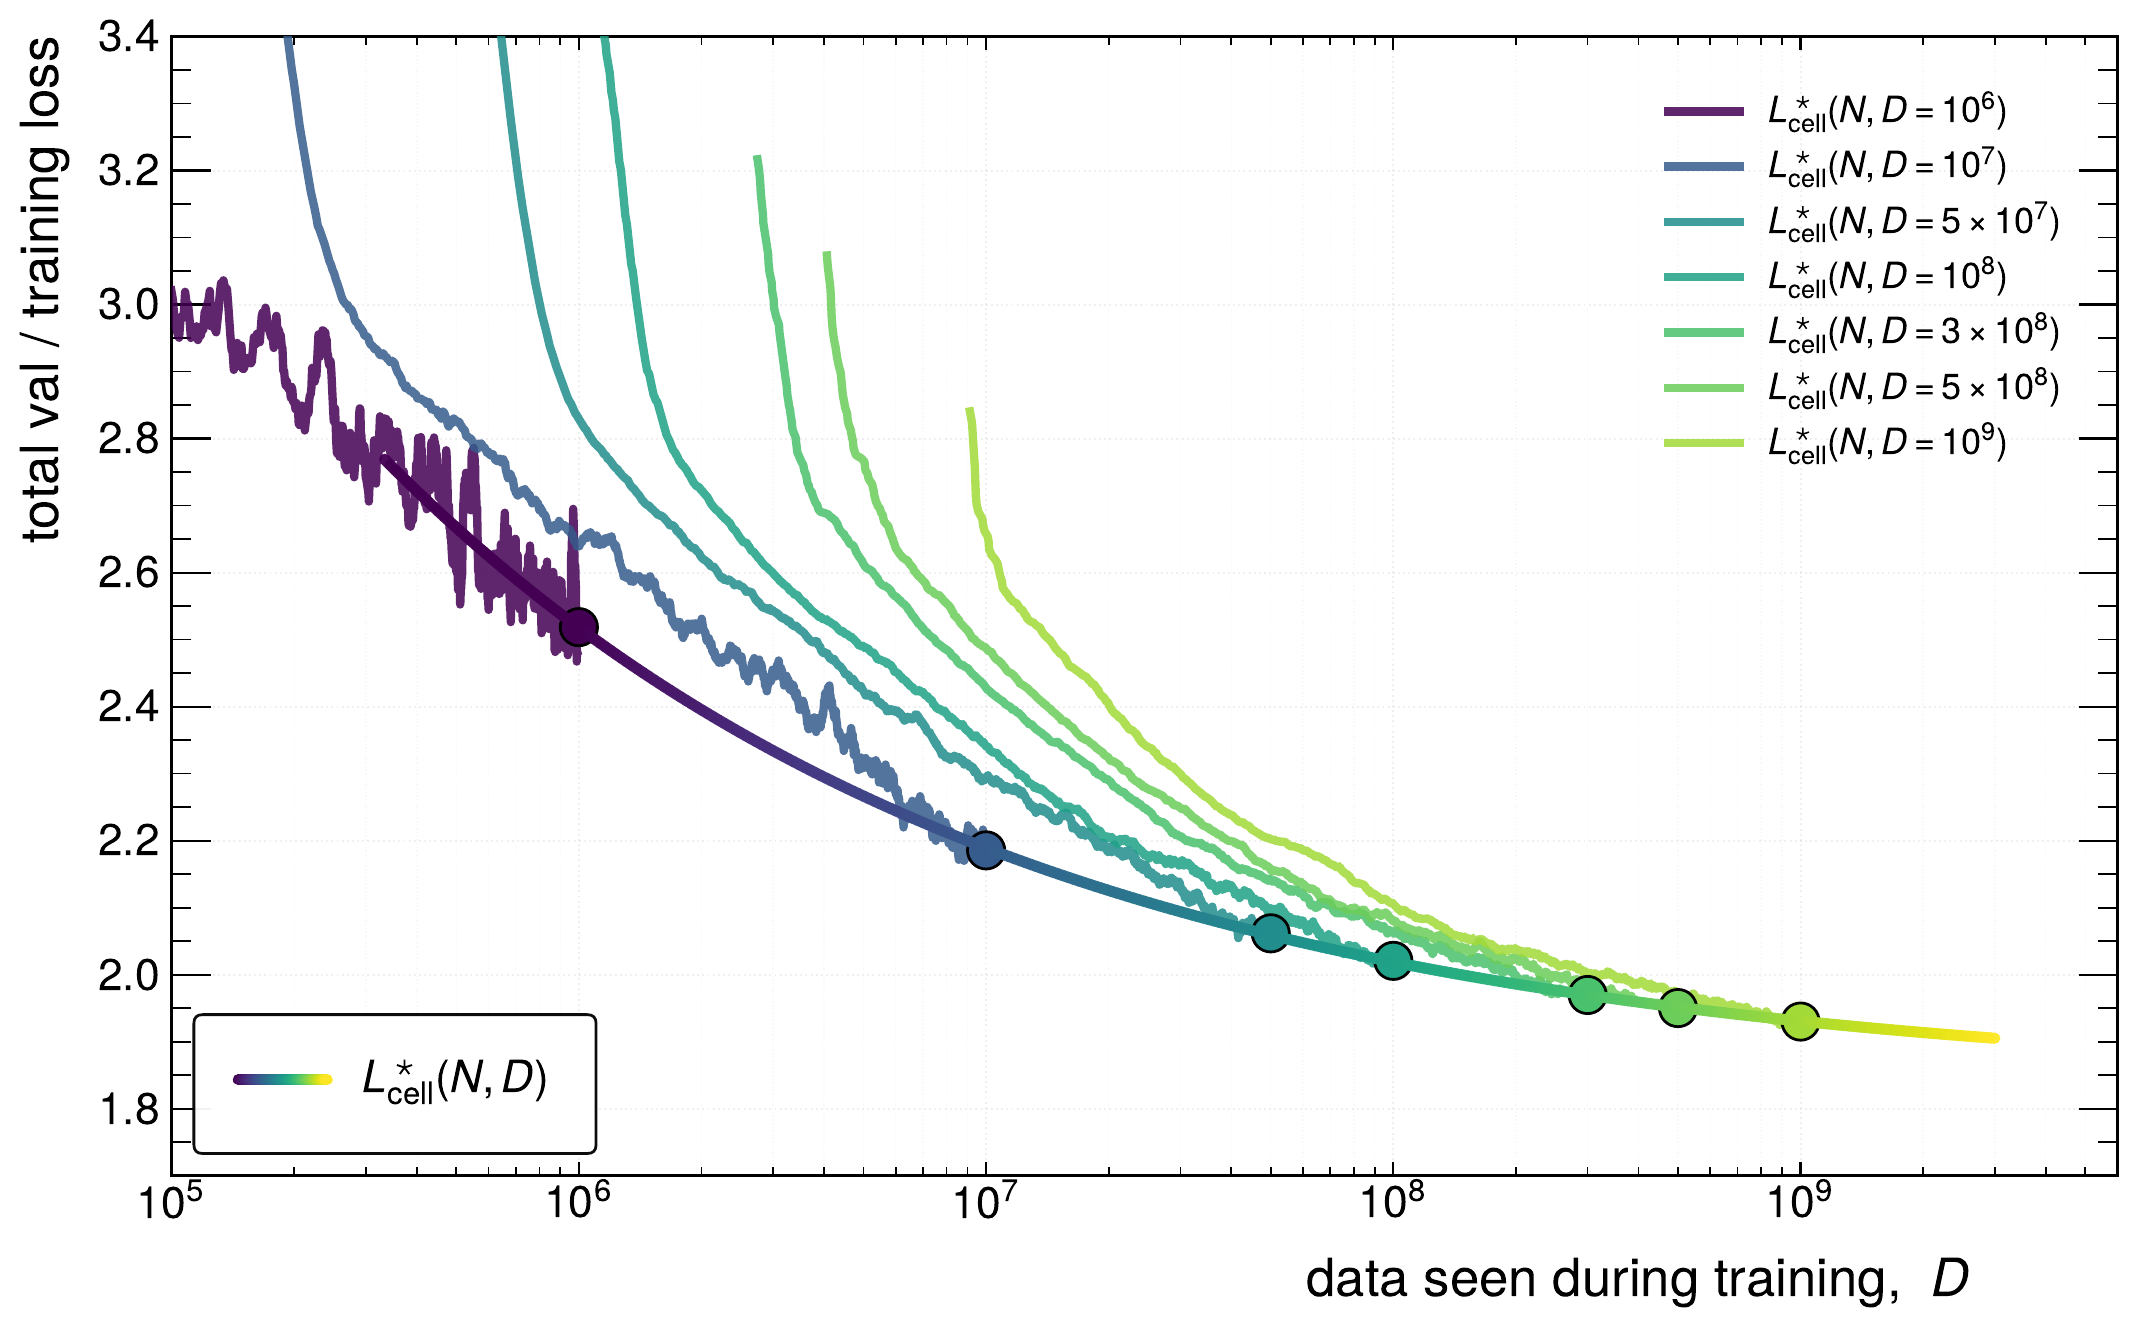

In [9]:
Image(filename=os.path.join(FIGDIR, "schedule_demo_W384_L4.png"))

### What if you *don't* re-tune? The cost along $D$ and along $N$

To make that cost concrete, [`run_lr_ablation.py`](../scripts/run_lr_ablation.py) (at $L{=}2$) holds **one fixed LR** — the value optimal
at the small end of an axis, and scales the other axis, against the fully per-cell-tuned baseline:

- **Left — scale $D$ at fixed width $w{=}64$.** An LR tuned at small $D$ is too *hot* once $D$ is large
  ($\eta^\star$ falls with the horizon), so the fixed-LR loss stops improving and eventually **rises**.
- **Right — scale $N$ (width) at fixed $D$.** An LR tuned at small $N$ is too hot once the net is wide
  (the μP shift), so again the fixed-LR loss flattens and **turns up** for the biggest models.

In both, the per-cell-tuned curve keeps descending; the gap (in reducible loss $L-E$) is the tuning
tax, and it *grows* with scale, which is exactly why reading scaling exponent off an un-tuned grid biases
it and can completely prevent scaling from happening.

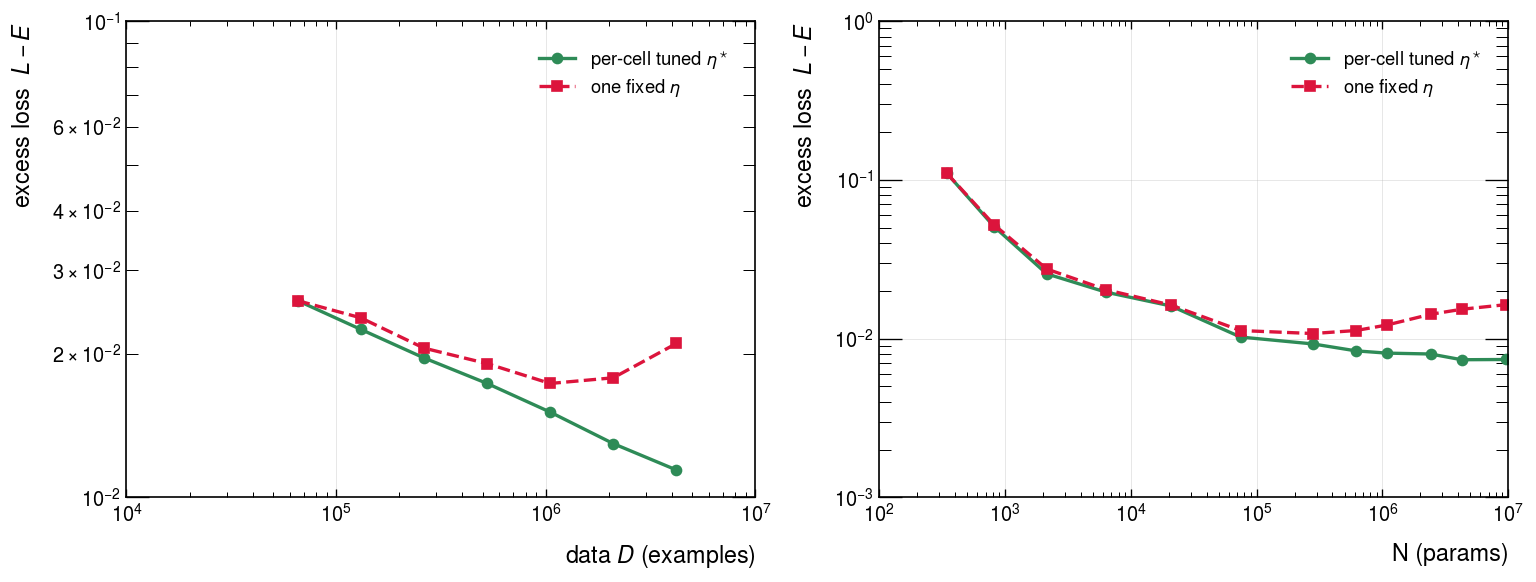

In [10]:
Image(filename=os.path.join(FIGDIR, "lr_ablation.png"))

### We *measure* the transfer law $\eta^\star(w,T)$

We don't tune every cell by brute force, we calibrate a law once and predict from it.
[`run_hp_study.py`](../scripts/run_hp_study.py) sweeps the LR at a handful of cells, takes the parabola minimum as $\eta^\star$,
and fits
$$\eta^\star(w,T)=\eta_{\rm ref}\,(w/w_{\rm ref})^{c_w}\,(T/T_{\rm ref})^{c_T},$$
the two pieces being the **μP width shift** ($\eta^\star$ falls with width) and the **horizon decay**
($\eta^\star$ falls with the step budget $T=D/b$, fit only for $T\ge256$ — shorter runs are
warmup-dominated). [`run_sweep.py`](../scripts/run_sweep.py) then launches **every cell at its predicted $\eta^\star$**.

- **Batch size is held fixed** at $b=256$ for simplicity. In principle $b$ should be tuned *jointly*
  with $\eta$ (the critical-batch $b^\star\propto\sqrt T$); we fix it and let the $T$-law above absorb the
  horizon dependence at that one batch size.
- **This is the single-pass / growing-horizon regime** — each example is seen once and $T$ grows with
  $D$. It is *not* the same as replaying a *limited* dataset for many epochs, where you overfit the
  noise and see double descent: that regime lives in
  [`02_double_descent.ipynb`](02_double_descent.ipynb).

per-cell LR law (cosine):  eta*(w,T) = 0.00535 * (w/64)^-0.374 * (T/2048)^-0.617


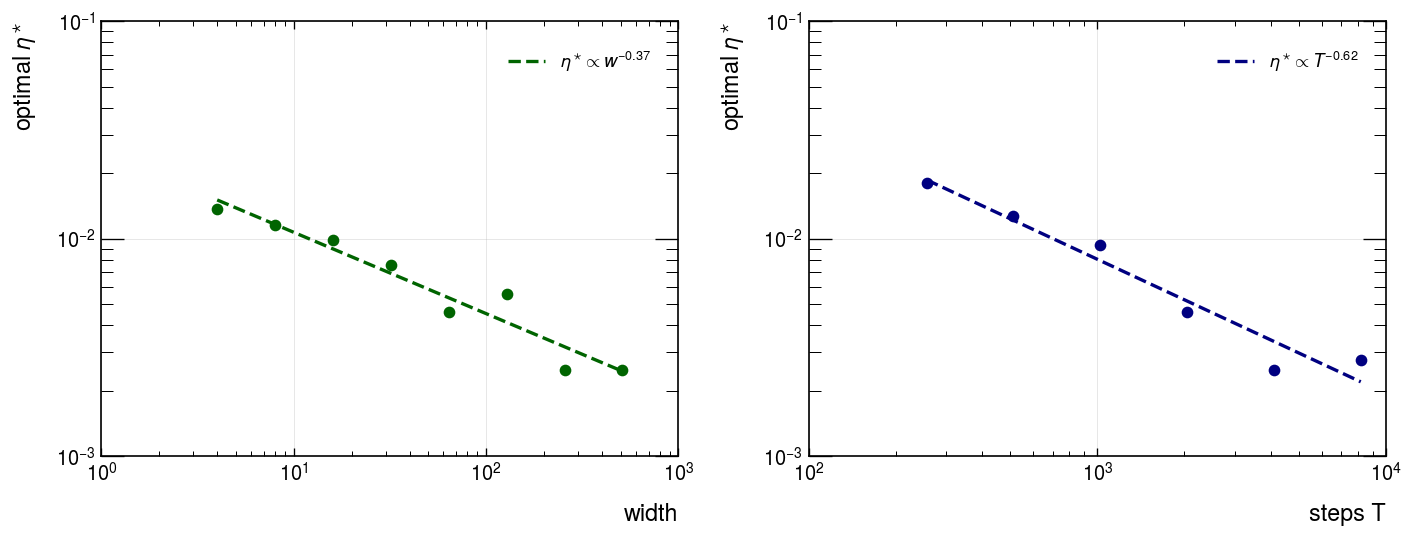

In [11]:
law = meta["cosine_lr_law"]
print("per-cell LR law (cosine):  eta*(w,T) = "
      f"{law['eta_ref']} * (w/{law['w_ref']})^{law['c_w']} * (T/{law['T_ref']})^{law['c_T']}")
Image(filename=os.path.join(FIGDIR, "hp_study_cosine.png"))

## All runs at a glance

**Protocol.** Train one student per size $N$ on a ladder of single-pass data budgets $D$, each
cell at its own predicted $\eta^\star$ ([`run_sweep.py`](../scripts/run_sweep.py)), and record the final validation loss.
That table of $(N, D, L)$ is the raw material every approach below works from.

**In code.** [`pl.plot_all_runs(agg)`](../scaling_laws/plotting.py#L44) should plots each cell two ways — loss vs **data** $D$ (left: each
model's training curve, flattening at its capacity) and loss vs **compute** $C=(6N-2dw)D$ (right).

<font color="red"><b>Q2a:</b></font> Fill in the blanks for implementing the function `pl.plot_all_runs` to create the plot below.

**Your answer:**

NotImplementedError: 

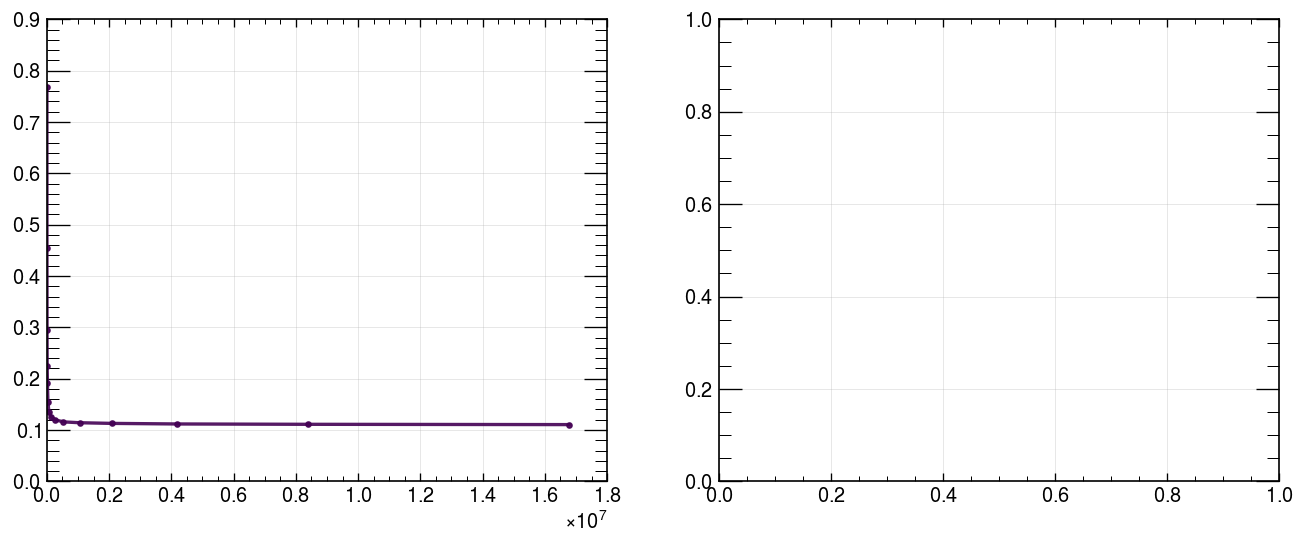

In [12]:
fig = pl.plot_all_runs(agg, irreducible=E_true)
pl.save_figure(fig, "01_overview", outdir=FIGDIR); plt.show()

<font color="red"><b>Q2b:</b></font> What did you learn?
* When do small models do better?
* When do large models do better?
* What about your prediction for $\mathcal{L}_\infty$, are we faaaar away, or did you overshoot it?

## Approach 1 — training-curve / lower envelope

**Idea.** A cell is compute-optimal if **no cheaper cell reached an equal-or-lower loss**.

**Protocol.** Sort every $(N,D)$ cell by compute $C$; sweep $C$ upward and keep each cell that
sets a new record-low loss. Those record-holders trace the frontier $L^\star(C)$, and their
$(N,D)$ are the optimal allocations — fit $N^\star\!\propto C^{a_N}$ and $D^\star\!\propto C^{a_D}$
(expect $a_N+a_D\approx1$). Nothing is assumed about the loss surface; the staircase look is
just the discrete grid.

**In code.** [`ap.training_curve_envelope(agg)`](../scaling_laws/approaches.py#L51) returns the frontier cells and the fitted
exponents; [`pl.plot_envelope`](../scaling_laws/plotting.py#L73) draws the point cloud, the Pareto staircase, and $N^\star(C)$,
$D^\star(C)$.

<font color="red"><b>Q3:</b></font> Finish the plotting code in [`pl.plot_envelope`](../scaling_laws/plotting.py#L73) to make this plot.

Approach 1:  N* ~ C^0.476,   D* ~ C^0.504   (35 frontier cells)
Q3: NEED TO IMPLEMENT


/content/scaling-laws-demo/scaling_laws/plotting.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].set_xlabel("C"); axes[2].set_ylabel(r"$D^\star$"); axes[2].legend(frameon=False)


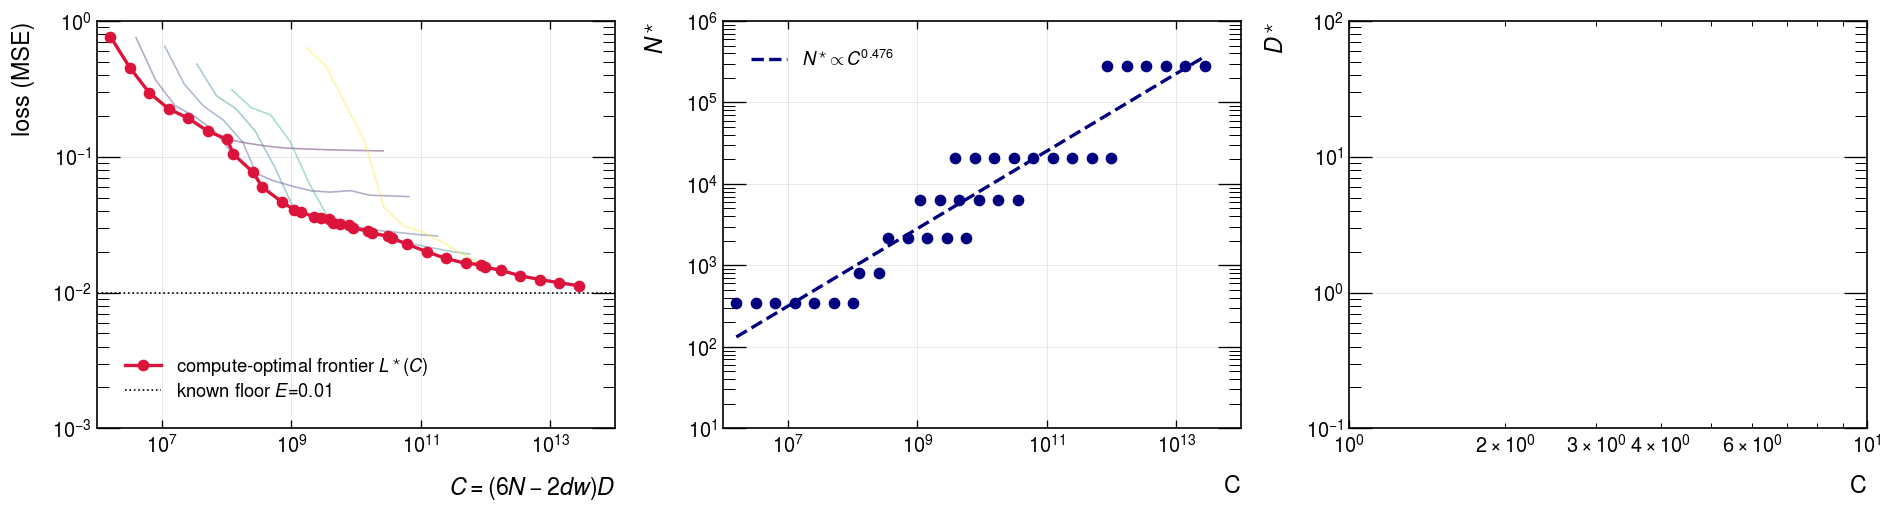

In [13]:
env = ap.training_curve_envelope(agg)
print(f"Approach 1:  N* ~ C^{env.a_N:.3f},   D* ~ C^{env.a_D:.3f}   ({len(env.frontier)} frontier cells)")
fig = pl.plot_envelope(agg, env, irreducible=E_true)
pl.save_figure(fig, "02_approach1_envelope", outdir=FIGDIR); plt.show()

## Approach 2 — IsoFLOP profiles

**Idea.** At a *fixed* compute budget there is a best model size — too small underfits, too large
starves for data.

**Protocol.** Pick a ladder of budgets $C$. At each one, **scan model size $N$ along the
iso-compute slice** $D=C/(6N{-}2dw)$ (reading every width's loss off the grid); the slice is
$\cup$-shaped in $\log N$, so fit a parabola and take its **interior** minimum $N^\star(C)$.
Connecting the minima across budgets gives the allocation $N^\star\!\propto C^{a_N}$.

**In code.** [`ap.isoflop_profiles(agg)`](../scaling_laws/approaches.py#L168) builds each slice, trims under-trained tails, fits the
parabola and reads the minimum; [`pl.plot_isoflop`](../scaling_laws/plotting.py#L107) shows the per-budget parabolas (stars = minima)
and the fitted $N^\star, D^\star$.

Approach 2:  N* ~ C^0.512,   D* ~ C^0.462   (10 slices)


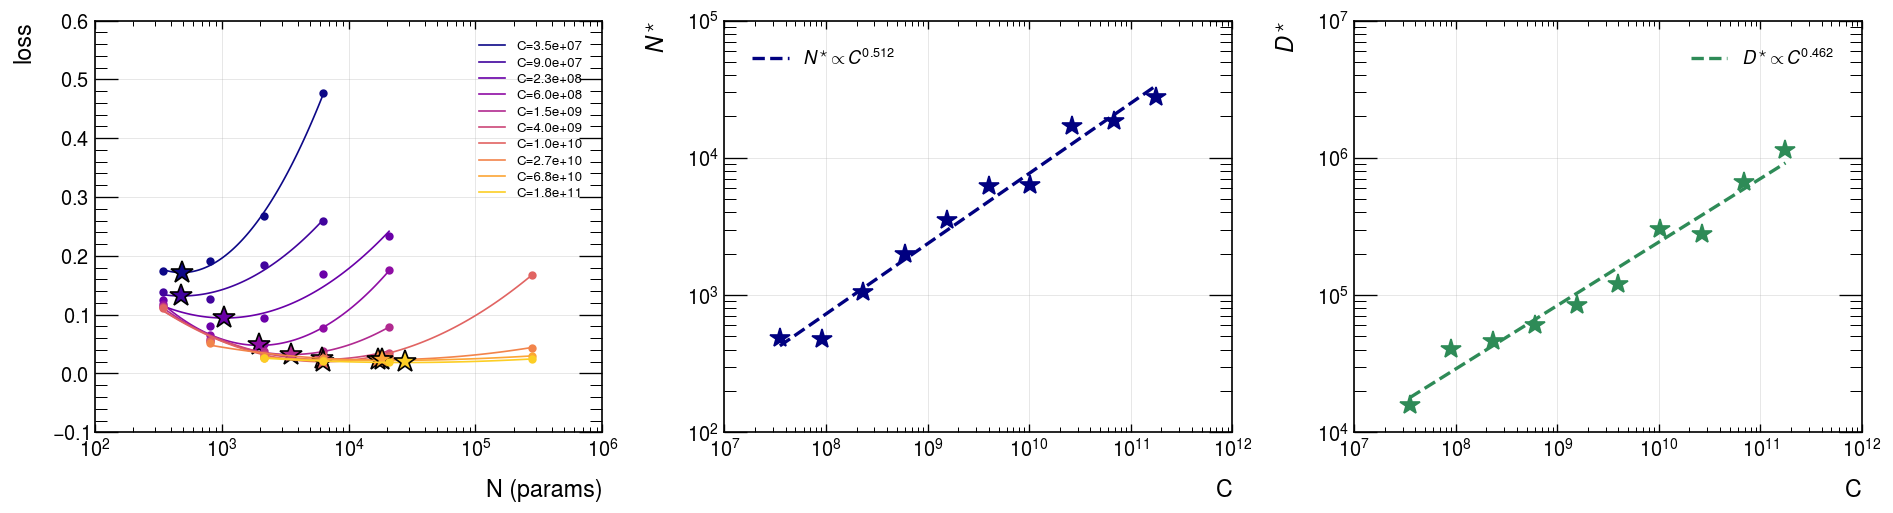

In [14]:
iso = ap.isoflop_profiles(agg, n_targets=10)
print(f"Approach 2:  N* ~ C^{iso.a_N:.3f},   D* ~ C^{iso.a_D:.3f}   ({len(iso.minima)} slices)")
fig = pl.plot_isoflop(iso)
pl.save_figure(fig, "03_approach2_isoflop", outdir=FIGDIR); plt.show()

<font color="red"><b>Q4:</b></font> How do the fitted coefficients compare between the two approaches?

**Your answer:**

## Approach 3 — parametric (additive "Chinchilla") surface

**Idea.** Don't slice the data — fit the entire loss surface at once.

**Protocol.** Fit $L(N,D)=L_\infty+A/N^\alpha+B/D^\beta$ to **all** cells jointly (Huber loss on
log-loss residuals; parameters carried in log-space so $L_\infty,A,B>0$). With $(\alpha,\beta)$ the
frontier is closed-form $N^\star\!\propto C^{\beta/(\alpha+\beta)}$ — and this is the **only**
approach that also estimates the floor $L_\infty$, which we grade against your prediction in **Q1**.

<font color="red"><b>Q5:</b></font> Derive the relation: $N^\star\!\propto C^{\beta/(\alpha+\beta)}$ for the compute optimal frontier.

Hint: Use the method of Lagrange multipliers with constraint $C = C_{budget}$

**Your answer:** (Also fine to work on paper)


**In code.** [`ap.parametric_fit(agg)`](../scaling_laws/approaches.py#L271) returns $(L_\infty,A,B,\alpha,\beta)$ and the derived frontier;
[`pl.plot_parametric`](../scaling_laws/plotting.py#L145) shows the fitted surface in the $(N,D)$ plane with the compute-optimal locus,
plus a fit-quality panel. The allocation exponents are robust; $E$ is the least-constrained.

<font color="red"><b>Q6:</b></font>
I commented out the parametric fit in the left figure.

**Your task:** Go into the `pl.plot_parametric`  and uncomment the predicted fit and see if the predicted colors agree with the empirically measured colors.

How does it look?

**Your answer:** (one sentence)

L(N,D) = 0.0125 + 30.9/N^0.983 + 182/D^0.819
Approach 3:  N* ~ C^0.455,   D* ~ C^0.545


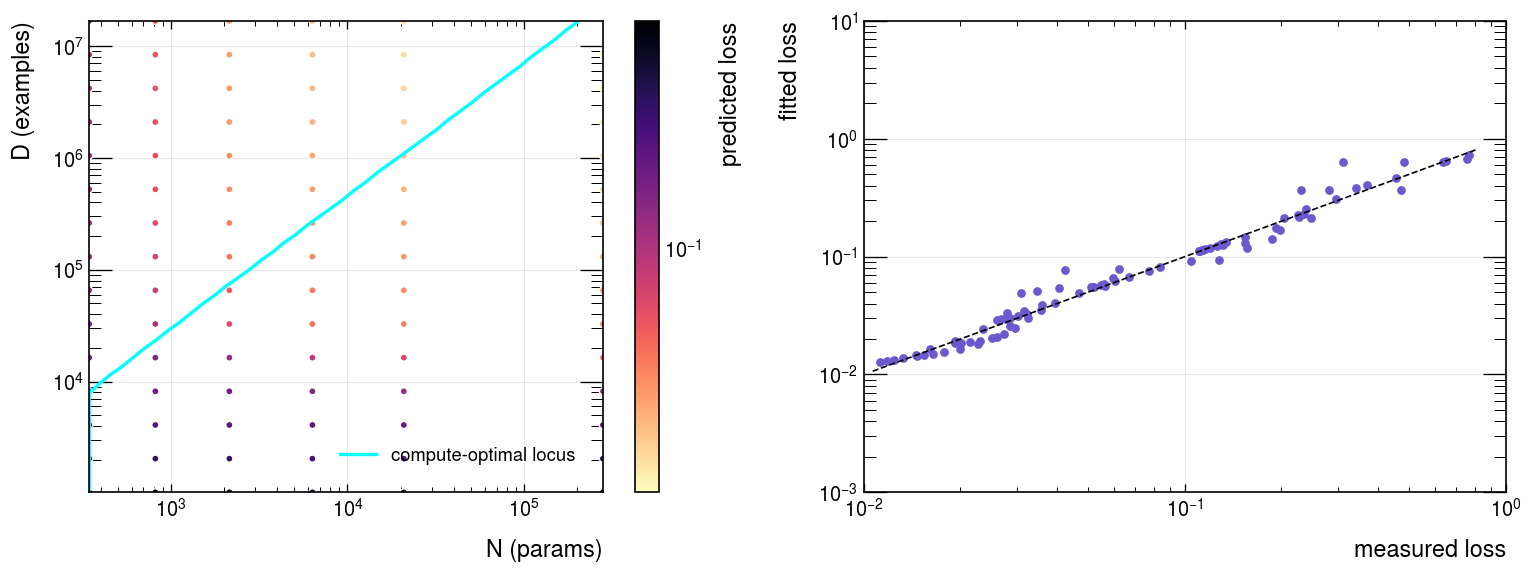

In [15]:
par = ap.parametric_fit(agg)
print(f"L(N,D) = {par.E:.4f} + {par.A:.3g}/N^{par.alpha:.3f} + {par.B:.3g}/D^{par.beta:.3f}")
print(f"Approach 3:  N* ~ C^{par.a_N:.3f},   D* ~ C^{par.a_D:.3f}")
fig = pl.plot_parametric(agg, par, irreducible=E_true)
pl.save_figure(fig, "04_approach3_parametric", outdir=FIGDIR); plt.show()

<font color="red"><b>Q7:</b></font> How does the fitted $L_\infty$ compare with the true $L_\infty$ you predicted in Q1?

**Your answer:**

## Do the three agree?

They should agree on the **allocation** even if they disagree on the floor. The left panel
overlays $N^\star(C)$; the table collects the exponents (and the floor, where defined).

In [ ]:
fig = pl.plot_comparison(env, iso, par, (agg["C"].min(), agg["C"].max()))
pl.save_figure(fig, "05_comparison", outdir=FIGDIR); plt.show()

summary = pd.DataFrame({
    "a_N (N*~C^a)": [env.a_N, iso.a_N, par.a_N],
    "a_D (D*~C^a)": [env.a_D, iso.a_D, par.a_D],
    "floor E":      [np.nan,  np.nan,  par.E],
}, index=["1: envelope", "2: isoflop", "3: parametric"])
print(f"(known floor E = {E_true})")
summary.round(3)

## Takeaways

- **Three methods, one frontier.** Envelope, IsoFLOP, and parametric fit recover a consistent
  compute-optimal allocation, here close to the equal $\sqrt C$ split: grow $N$ and $D$ **together**.
- **Trust the allocation, less the floor.** $(N^\star,D^\star)$ are robust across methods; the
  fitted $E$ is comes from a single method and is more prone to extrapolation uncertainties and mis-tuning.
- **A scaling law presupposes hyperparameter tuning.** Each cell was launched at its own predicted
  $\eta^\star(w,T)$; with one fixed LR the wide/long-run cells would be mis-tuned and the exponents
  biased.


### <font color="red">Q8: Wrap-up</font>

Is there a problem you would like to test the scaling behavior of in your research?
- What would you need (resources, data) to set up the project
- What tests could you run to verify scaling is working in your problem?
- What impact would this knowledge have for your research program?

Discuss your ideas with your neighbor!!

The rest of the nb is for your enjoyment. We don't more questions!

### Caveats
- **Batch size held fixed.** We tune $\eta$ per cell but hold $b=256$; jointly tuning $(b,\eta)$ is the natural next step.

### Reproduce
```bash
pip install -r requirements.txt
python scripts/run_hp_study.py      # ~10 min: calibrate the per-cell LR law
python scripts/run_sweep.py         # ~45 min: train the (N,D) grid out to 17M examples
                                    #          (--preset quick for a fast smoke test)
# then run this notebook top to bottom; figures export to results/figures/*.pdf
```

The sweep is *incremental*: re-running after extending the data/width range only
trains the genuinely new cells (single-pass training is linear in D, so the cost is
dominated by the largest data budget).

## Scaling $N$ by depth

So far $N$ grew by **width** at a fixed depth of 2 hidden layers. [`scripts/run_depth_compare.py`](../scripts/run_depth_compare.py)
adds **1- and 6-layer** families on the same teacher (each with its own LR calibration, since
depth shifts $\eta^\star$) and compares fixed-depth and combined scaling. Deciding how to actually increse the model size of a given architecture (here simply width and depth) is also part of the optimization work one needs to do when properly scaling.

In [ ]:
from IPython.display import Image
Image(filename=os.path.join(FIGDIR, 'depth_comparison.png'))

<a id="flop-appendix"></a>
## Appendix: does $C=(6N-2dw)D$ match a real FLOP count?

The formula is a *leading-order* count (matmuls only). Before relying on it, check it against an
actual measurement from PyTorch's `FlopCounterMode`, which traces the ops of a real forward+backward
pass.

**Protocol.** For a ladder of widths, run one fwd+bwd on a batch under `FlopCounterMode`, divide the
total FLOPs by the batch size, and compare the measurement to the closed form
[`flops_per_token`](../scaling_laws/flops.py#L40) $=6N-2dw$ and to the naive $6N$
([`pl.plot_flop_validation`](../scaling_laws/plotting.py#L257) draws it).

In [ ]:
import sys
# Colab: ensure the cloned repo is importable even if the setup cell above is stale
if "google.colab" in sys.modules and "/content/scaling-laws-demo" not in sys.path:
    sys.path.insert(0, "/content/scaling-laws-demo")

import torch
from torch.utils.flop_counter import FlopCounterMode
from scaling_laws.models import make_mlp
from scaling_laws.flops import mlp_param_count, flops_per_token

def measured_flops_per_example(width, n_hidden=2, d=32, B=512):
    net = make_mlp(d, width, n_hidden, 1)
    x = torch.randn(B, d)                 # requires_grad=False -> autograd skips the first
    fc = FlopCounterMode(display=False)   #   layer's input gradient (the -2dw term)
    with fc:
        net(x).square().mean().backward()
    return fc.get_total_flops() / B

flopval = pd.DataFrame([
    dict(width=w, N=(N := mlp_param_count(32, w, 2)),
         measured=measured_flops_per_example(w),
         formula=flops_per_token(N, 32, w), naive=6 * N)
    for w in [8, 16, 32, 64, 128, 256, 512, 1024]
])
fig = pl.plot_flop_validation(flopval)
pl.save_figure(fig, "06_flop_validation", outdir=FIGDIR); plt.show()
print(flopval.assign(**{"meas/(6N-2dw)": (flopval.measured / flopval.formula).round(3),
                        "meas/6N":       (flopval.measured / flopval.naive).round(3)}
                     ).to_string(index=False))